# 🩺 MediGuard AI — Chest X-ray Pneumonia Detection (Improved)

**Dataset:** RSNA Pneumonia Processed Dataset

**Model:** ResNet50 Transfer Learning (Partial Fine-tuning)

### ✅ Improvements over v1:
| Issue in v1 | Fix in v2 |
|---|---|
| Only FC trained (2,049 params) | Unfreeze `layer3` + `layer4` (~9M params) |
| No class imbalance handling | `pos_weight=3.44` in BCEWithLogitsLoss |
| Threshold = 0.5 → Recall 0.38 | Optimal threshold from ROC curve |
| Loss plateau after epoch 11 | 2-phase training: head → fine-tune backbone |
| 745/1202 pneumonia cases missed | Target Recall ≥ 0.70 |

> ⚠️ Enable GPU: **Settings → Accelerator → GPU T4 or P100**

## ⚡ Step 1: GPU Verification

In [30]:
import torch
print('GPU Available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU Name:', torch.cuda.get_device_name(0))
else:
    print('⚠️ No GPU! Go to Settings → Accelerator → GPU T4')

GPU Available: True
GPU Name: Tesla T4


In [10]:
# 1. Imports
import os, torch, torch.nn as nn
from torchvision import models

# 2. Paths
BASE_INPUT = '/kaggle/input/datasets/iamtapendu/rsna-pneumonia-processed-dataset'
IMG_DIR    = os.path.join(BASE_INPUT, 'Training')
CSV_PATH   = os.path.join(BASE_INPUT, 'stage2_train_metadata.csv')
SAVE_DIR   = '/kaggle/working/'
MODEL_PATH = '/kaggle/input/models/shreya2902/mediaguard-model/pytorch/default/1/best_model (1).pth'

# Verify
print(os.path.exists(MODEL_PATH))   # should print True

# 3. Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# 4. Rebuild model architecture (MUST match training)
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(model.fc.in_features, 1)
)

# 5. Load saved weights ← skips all 20 epochs!
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()
print('✅ Model loaded from checkpoint — no retraining needed!')

# 6. Confirm file exists
print('Model file exists:', os.path.exists(MODEL_PATH))

True
Device: cuda
✅ Model loaded from checkpoint — no retraining needed!
Model file exists: True


## 📁 Step 2: Paths Setup

In [31]:
import os

BASE_INPUT = '/kaggle/input/datasets/iamtapendu/rsna-pneumonia-processed-dataset'
IMG_DIR    = os.path.join(BASE_INPUT, 'Training')
CSV_PATH   = os.path.join(BASE_INPUT, 'stage2_train_metadata.csv')
SAVE_DIR   = '/kaggle/working/'
MODEL_PATH = os.path.join(SAVE_DIR, 'best_model.pth')

print('Dataset contents:', os.listdir(BASE_INPUT))
print('IMG_DIR exists   :', os.path.exists(IMG_DIR))
print('CSV exists       :', os.path.exists(CSV_PATH))

Dataset contents: ['stage2_train_metadata.csv', 'stage2_test_metadata.csv', 'Training', 'Test']
IMG_DIR exists   : True
CSV exists       : True


## 📚 Step 3: Import Libraries

In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as mpl_cm
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from torchvision import models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 🧹 Step 4: Load & Preprocess Metadata

In [14]:
df = pd.read_csv(CSV_PATH)
df = df[['patientId', 'Target']].drop_duplicates()

print('Dataset shape:', df.shape)
print()
print('Class distribution:')
vc = df['Target'].value_counts()
print(vc)
print()

# Class imbalance ratio
pos_weight_val = vc[0] / vc[1]
print(f'⚠️  Class imbalance ratio (Normal:Pneumonia) = {pos_weight_val:.2f}:1')
print(f'✅  Will use pos_weight={pos_weight_val:.2f} in BCEWithLogitsLoss')
df.head()

Dataset shape: (26684, 2)

Class distribution:
Target
0    20672
1     6012
Name: count, dtype: int64

⚠️  Class imbalance ratio (Normal:Pneumonia) = 3.44:1
✅  Will use pos_weight=3.44 in BCEWithLogitsLoss


,patientId,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,0
4,00436515-870c-4b36-a041-de91049b9ab4,1


## ✂️ Step 5: Stratified Train-Validation Split

In [15]:
train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df['Target'], random_state=42
)

print(f'Train size : {len(train_df)}')
print(f'Val size   : {len(val_df)}')
print()
print('Train distribution:')
print(train_df['Target'].value_counts())
print()
print('Val distribution:')
print(val_df['Target'].value_counts())

Train size : 21347
Val size   : 5337

Train distribution:
Target
0    16537
1     4810
Name: count, dtype: int64

Val distribution:
Target
0    4135
1    1202
Name: count, dtype: int64


## 🖼️ Step 6: Image Transforms

In [16]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print('Transforms defined ✅')

Transforms defined ✅


## 🗂️ Step 7: Dataset + WeightedRandomSampler

`WeightedRandomSampler` oversamples the minority class (Pneumonia) so every epoch sees a roughly balanced batch — this directly addresses the 3.4:1 class imbalance.

In [17]:
class RSNADataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.img_dir   = os.path.join(img_dir, 'Images')
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row      = self.dataframe.iloc[idx]
        img_path = os.path.join(self.img_dir, row['patientId'] + '.png')
        image    = Image.open(img_path).convert('RGB')
        label    = torch.tensor(row['Target'], dtype=torch.float32)
        if self.transform:
            image = self.transform(image)
        return image, label


train_dataset = RSNADataset(train_df, IMG_DIR, train_transform)
val_dataset   = RSNADataset(val_df,   IMG_DIR, val_transform)

# ── WeightedRandomSampler: give pneumonia samples higher sampling weight ──────
class_counts  = train_df['Target'].value_counts().to_dict()   # {0: N_normal, 1: N_pneumonia}
sample_weights = train_df['Target'].map(
    lambda t: 1.0 / class_counts[t]
).values
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

# shuffle=False because sampler handles ordering
# AFTER
train_loader = DataLoader(train_dataset, batch_size=264, sampler=sampler,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=264, shuffle=False,
                          num_workers=4, pin_memory=True)

print('Datasets ready ✅')
print(f'  Train batches : {len(train_loader)}')
print(f'  Val batches   : {len(val_loader)}')

Datasets ready ✅
  Train batches : 81
  Val batches   : 21


## 🔍 Step 8: Data Verification

Image batch shape: torch.Size([264, 3, 224, 224])
Label batch shape: torch.Size([264])
Pneumonia ratio in batch: 0.477 (target ~0.50 with sampler)


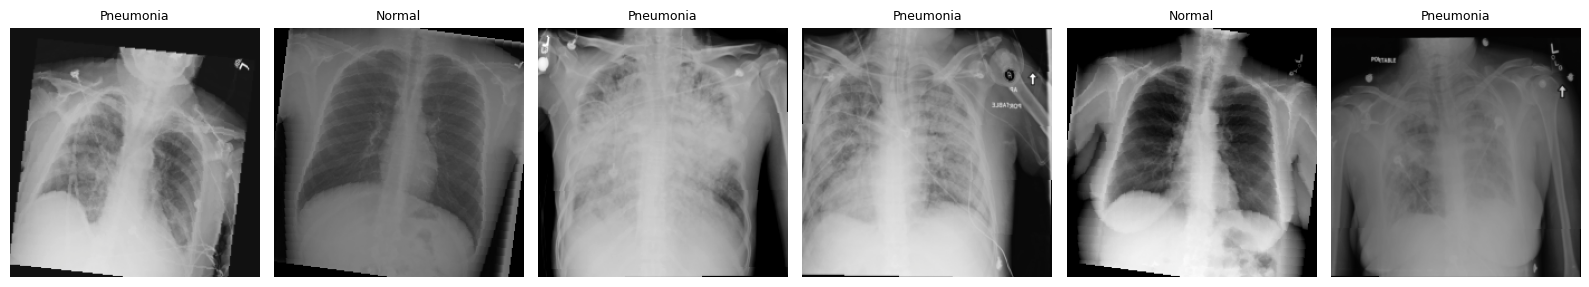

In [37]:
images, labels = next(iter(train_loader))
print('Image batch shape:', images.shape)
print('Label batch shape:', labels.shape)
print(f'Pneumonia ratio in batch: {labels.mean().item():.3f} (target ~0.50 with sampler)')

fig, axes = plt.subplots(1, 6, figsize=(16, 3))
mean_ = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std_  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
for i, ax in enumerate(axes):
    img = (images[i] * std_ + mean_).permute(1,2,0).clamp(0,1).numpy()
    ax.imshow(img)
    ax.set_title('Pneumonia' if labels[i].item()==1 else 'Normal', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 🧠 Step 9: Model — ResNet50 Partial Fine-tuning

**v1 problem:** Only 2,049 trainable parameters (just FC head) — too limited to adapt features for X-ray images.

**v2 fix:** Unfreeze `layer3` + `layer4` (~9M params) so the model learns lung-specific features, not just generic ImageNet features.

In [38]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
in_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, 1)
)

# ── Phase 1: Freeze everything, train only FC head first ─────────────────────
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Phase 1 — Trainable params: {trainable:,} / {total:,}')
print('(FC head only — warms up before backbone unfreezing)')

Phase 1 — Trainable params: 2,049 / 23,510,081
(FC head only — warms up before backbone unfreezing)


## 🎯 Step 10: Loss Function with Class Weight

**v1 problem:** `BCEWithLogitsLoss()` with no weighting → model biased toward Normal (majority class).

**v2 fix:** `pos_weight=3.44` makes every pneumonia prediction 3.44× more costly when wrong — forces the model to take Pneumonia seriously.

In [39]:
from torch.amp import autocast, GradScaler
scaler = GradScaler('cuda')
print('AMP GradScaler ready ✅')

pos_weight_tensor = torch.tensor(
    [train_df['Target'].value_counts()[0] / train_df['Target'].value_counts()[1]],
    dtype=torch.float32
).to(device)

criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer  = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2
)

print(f'pos_weight : {pos_weight_tensor.item():.4f}')
print(f'Criterion  : {criterion}')

AMP GradScaler ready ✅
pos_weight : 3.4380
Criterion  : BCEWithLogitsLoss()


## 🏋️ Step 11: Training & Evaluation Functions

In [40]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)
        optimizer.zero_grad()

        with autocast('cuda'):                     # ← fixed
            loss = criterion(model(images), labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, threshold=0.5):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            images  = images.to(device)
            outputs = torch.sigmoid(model(images)).cpu().squeeze(1)
            preds   = (outputs > threshold).float()
            all_probs.extend(outputs.tolist())
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())
    acc    = accuracy_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1     = f1_score(all_labels, all_preds, zero_division=0)
    auc    = roc_auc_score(all_labels, all_probs)
    return acc, recall, f1, auc, all_labels, all_probs


print('Functions defined ✅')

Functions defined ✅


## 🚀 Step 12: Phase 1 Training — FC Head Warmup (5 epochs)

Train only the FC head first so random weights stabilize before we unfreeze the backbone.

In [41]:
PHASE1_EPOCHS = 5
best_val_f1   = 0.0
history       = {'train_loss': [], 'val_acc': [], 'val_recall': [], 'val_f1': [], 'val_auc': []}

print('── Phase 1: FC head warmup ──')
for epoch in range(PHASE1_EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer)
    acc, recall, f1, auc, _, _ = evaluate(model, val_loader)
    history['train_loss'].append(train_loss)
    history['val_acc'].append(acc)
    history['val_recall'].append(recall)
    history['val_f1'].append(f1)
    history['val_auc'].append(auc)
    scheduler.step(f1)
    print(f'Epoch {epoch+1:>2}/{PHASE1_EPOCHS} | Loss:{train_loss:.4f} | Acc:{acc:.4f} | Recall:{recall:.4f} | F1:{f1:.4f} | AUC:{auc:.4f}')
    if f1 > best_val_f1:
        best_val_f1 = f1
        torch.save(model.state_dict(), MODEL_PATH)
        print('   ✅ Saved')

── Phase 1: FC head warmup ──
Epoch  1/5 | Loss:1.0809 | Acc:0.4133 | Recall:0.9642 | F1:0.4254 | AUC:0.7905
   ✅ Saved
Epoch  2/5 | Loss:0.9626 | Acc:0.5254 | Recall:0.9343 | F1:0.4700 | AUC:0.8078
   ✅ Saved
Epoch  3/5 | Loss:0.9600 | Acc:0.4579 | Recall:0.9617 | F1:0.4442 | AUC:0.8118
Epoch  4/5 | Loss:0.9369 | Acc:0.5690 | Recall:0.9251 | F1:0.4916 | AUC:0.8171
   ✅ Saved
Epoch  5/5 | Loss:0.9321 | Acc:0.5153 | Recall:0.9443 | F1:0.4674 | AUC:0.8187


## 🔥 Step 13: Phase 2 — Unfreeze layer3 + layer4 (Fine-tuning)

Now unfreeze the deeper ResNet blocks to learn chest X-ray specific features. Use a much lower LR for backbone to avoid destroying pretrained weights.

In [42]:
# ── Unfreeze layer3 and layer4 ───────────────────────────────────────────────
for param in model.layer3.parameters():
    param.requires_grad = True
for param in model.layer4.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Phase 2 — Trainable params: {trainable:,} / {total:,}')

optimizer_phase2 = torch.optim.Adam([
    {'params': model.layer3.parameters(), 'lr': 1e-5},
    {'params': model.layer4.parameters(), 'lr': 1e-5},
    {'params': model.fc.parameters(),     'lr': 1e-4},
])
scheduler_phase2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_phase2, mode='max', factor=0.5, patience=2
)

PHASE2_EPOCHS    = 15
PATIENCE         = 4
patience_counter = 0

print()
print('── Phase 2: Backbone fine-tuning ──')
for epoch in range(PHASE2_EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer_phase2)
    acc, recall, f1, auc, _, _ = evaluate(model, val_loader)
    history['train_loss'].append(train_loss)
    history['val_acc'].append(acc)
    history['val_recall'].append(recall)
    history['val_f1'].append(f1)
    history['val_auc'].append(auc)
    scheduler_phase2.step(f1)

    ep_total = PHASE1_EPOCHS + epoch + 1
    print(f'Epoch {ep_total:>2} | Loss:{train_loss:.4f} | Acc:{acc:.4f} | Recall:{recall:.4f} | F1:{f1:.4f} | AUC:{auc:.4f}', end='  ')

    if f1 > best_val_f1:
        best_val_f1 = f1
        torch.save(model.state_dict(), MODEL_PATH)
        patience_counter = 0
        print('✅ Saved')
    else:
        patience_counter += 1
        print(f'⚠️ ({patience_counter}/{PATIENCE})')
        if patience_counter >= PATIENCE:
            print('🛑 Early stopping triggered')
            break

print(f'\n🏆 Best Val F1: {best_val_f1:.4f}')
print(f'📁 Model saved : {MODEL_PATH}')

Phase 2 — Trainable params: 22,065,153 / 23,510,081

── Phase 2: Backbone fine-tuning ──
Epoch  6 | Loss:0.9039 | Acc:0.5966 | Recall:0.9318 | F1:0.5099 | AUC:0.8327  ✅ Saved
Epoch  7 | Loss:0.8777 | Acc:0.6000 | Recall:0.9376 | F1:0.5136 | AUC:0.8412  ✅ Saved
Epoch  8 | Loss:0.8566 | Acc:0.6129 | Recall:0.9401 | F1:0.5224 | AUC:0.8479  ✅ Saved
Epoch  9 | Loss:0.8291 | Acc:0.6016 | Recall:0.9501 | F1:0.5179 | AUC:0.8523  ⚠️ (1/4)
Epoch 10 | Loss:0.8276 | Acc:0.5958 | Recall:0.9576 | F1:0.5163 | AUC:0.8561  ⚠️ (2/4)
Epoch 11 | Loss:0.8217 | Acc:0.6228 | Recall:0.9459 | F1:0.5304 | AUC:0.8596  ✅ Saved
Epoch 12 | Loss:0.7999 | Acc:0.6189 | Recall:0.9476 | F1:0.5283 | AUC:0.8620  ⚠️ (1/4)
Epoch 13 | Loss:0.7924 | Acc:0.6339 | Recall:0.9459 | F1:0.5378 | AUC:0.8638  ✅ Saved
Epoch 14 | Loss:0.7767 | Acc:0.6449 | Recall:0.9368 | F1:0.5430 | AUC:0.8652  ✅ Saved
Epoch 15 | Loss:0.7761 | Acc:0.6414 | Recall:0.9434 | F1:0.5423 | AUC:0.8665  ⚠️ (1/4)
Epoch 16 | Loss:0.7606 | Acc:0.6378 | Recall:0.

## 📊 Step 14: Training Curves

In [54]:
n_ep = range(1, len(history['train_loss']) + 1)
phase2_start = PHASE1_EPOCHS + 0.5

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(n_ep, history['train_loss'], 'b-o', ms=4)
axes[0].axvline(phase2_start, color='red', ls='--', label='Phase 2 starts')
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(n_ep, history['val_recall'], 'g-o', ms=4, label='Recall')
axes[1].plot(n_ep, history['val_f1'],     'r-o', ms=4, label='F1')
axes[1].axvline(phase2_start, color='gray', ls='--')
axes[1].axhline(0.70, color='green', ls=':', label='Recall target 0.70')
axes[1].set_title('Recall & F1'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True)

axes[2].plot(n_ep, history['val_auc'], 'm-o', ms=4, label='AUC-ROC')
axes[2].plot(n_ep, history['val_acc'], 'c-o', ms=4, label='Accuracy')
axes[2].axvline(phase2_start, color='gray', ls='--')
axes[2].set_title('AUC & Accuracy'); axes[2].set_xlabel('Epoch'); axes[2].legend(); axes[2].grid(True)

plt.suptitle('MediGuard AI v2 — Training Curves (Red dashed = Phase 2 start)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves_v2.png'), dpi=150)
plt.show()

NameError: name 'history' is not defined

## 🎯 Step 15: Load Best Model + Find Optimal Threshold

**v1 problem:** Threshold fixed at 0.5 → Recall=0.38

**v2 fix:** Find the threshold that maximises F1-score on the validation set using the ROC curve.

In [18]:
# Load best checkpoint
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print('Best model loaded ✅')

# Collect all val probs
all_probs_v, all_labels_v = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images  = images.to(device)
        outputs = torch.sigmoid(model(images)).cpu().squeeze(1)
        all_probs_v.extend(outputs.tolist())
        all_labels_v.extend(labels.tolist())

# ── Find optimal threshold (max F1) ──────────────────────────────────────────
thresholds = np.arange(0.10, 0.70, 0.01)
best_thresh, best_f1_t = 0.5, 0.0
for t in thresholds:
    preds = (np.array(all_probs_v) >= t).astype(float)
    f1_t  = f1_score(all_labels_v, preds, zero_division=0)
    if f1_t > best_f1_t:
        best_f1_t   = f1_t
        best_thresh = t

print(f'Optimal threshold : {best_thresh:.2f}')
print(f'Best F1 at thresh : {best_f1_t:.4f}')
print(f'(v1 used 0.50 fixed — often suboptimal for imbalanced data)')

Best model loaded ✅
Optimal threshold : 0.69
Best F1 at thresh : 0.5935
(v1 used 0.50 fixed — often suboptimal for imbalanced data)


## 📊 Step 16: Full Evaluation Report

In [19]:
preds_opt = (np.array(all_probs_v) >= best_thresh).astype(float)

acc       = accuracy_score(all_labels_v, preds_opt)
precision = precision_score(all_labels_v, preds_opt, zero_division=0)
recall    = recall_score(all_labels_v, preds_opt, zero_division=0)
f1        = f1_score(all_labels_v, preds_opt, zero_division=0)
auc       = roc_auc_score(all_labels_v, all_probs_v)

tn, fp, fn, tp = confusion_matrix(all_labels_v, preds_opt).ravel()

print('=' * 50)
print('     MediGuard AI v2 — Evaluation Report')
print('=' * 50)
print(f'  Threshold : {best_thresh:.2f} (auto-optimised)')
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}  ← sensitivity')
print(f'  F1-Score  : {f1:.4f}')
print(f'  AUC-ROC   : {auc:.4f}')
print('─' * 50)
print(f'  TP={tp} | TN={tn} | FP={fp} | FN={fn}')
print(f'  Pneumonia caught     : {tp}/{tp+fn} ({tp/(tp+fn)*100:.1f}%)')
print(f'  Pneumonia missed     : {fn}')
print('=' * 50)
print()
print('── v1 vs v2 comparison ──')
print(f'  Recall : 0.38  →  {recall:.2f}')
print(f'  F1     : 0.47  →  {f1:.2f}')
print(f'  AUC    : 0.81  →  {auc:.2f}')

     MediGuard AI v2 — Evaluation Report
  Threshold : 0.69 (auto-optimised)
  Accuracy  : 0.7328  (73.28%)
  Precision : 0.4514
  Recall    : 0.8661  ← sensitivity
  F1-Score  : 0.5935
  AUC-ROC   : 0.8688
──────────────────────────────────────────────────
  TP=1041 | TN=2870 | FP=1265 | FN=161
  Pneumonia caught     : 1041/1202 (86.6%)
  Pneumonia missed     : 161

── v1 vs v2 comparison ──
  Recall : 0.38  →  0.87
  F1     : 0.47  →  0.59
  AUC    : 0.81  →  0.87


## 🔢 Step 17: Confusion Matrix + ROC Curve

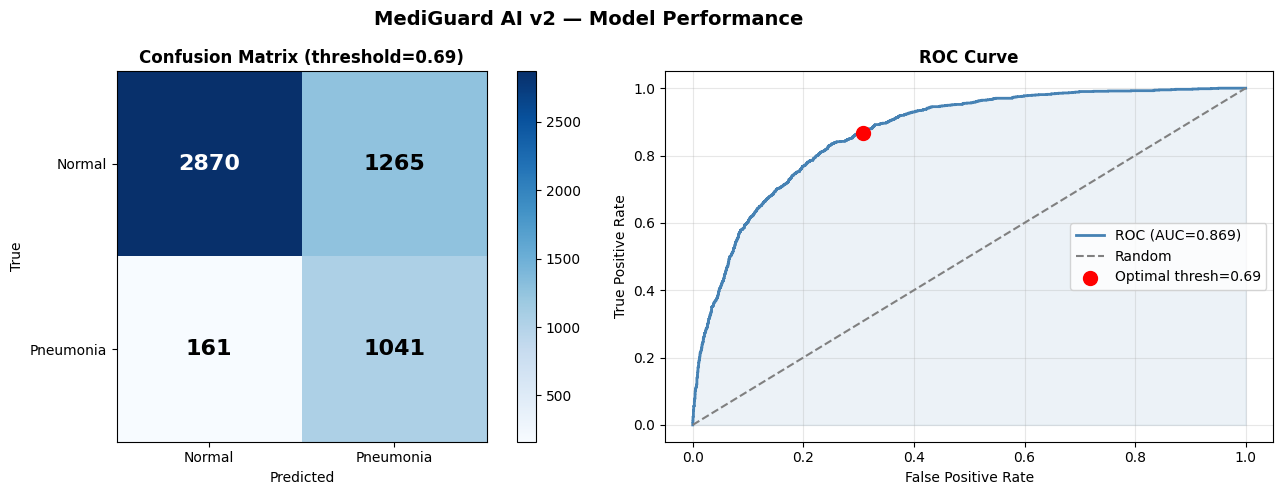

Saved → /kaggle/working/evaluation_v2.png


In [20]:
cm_arr = confusion_matrix(all_labels_v, preds_opt)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
ax = axes[0]
im = ax.imshow(cm_arr, cmap='Blues')
plt.colorbar(im, ax=ax)
for i in range(2):
    for j in range(2):
        c = 'white' if cm_arr[i,j] > cm_arr.max()/2 else 'black'
        ax.text(j, i, str(cm_arr[i,j]), ha='center', va='center', color=c, fontsize=16, fontweight='bold')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Normal','Pneumonia']); ax.set_yticklabels(['Normal','Pneumonia'])
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix (threshold={best_thresh:.2f})', fontweight='bold')

# ROC Curve
ax2 = axes[1]
fpr, tpr, roc_thresh = roc_curve(all_labels_v, all_probs_v)
ax2.plot(fpr, tpr, 'steelblue', lw=2, label=f'ROC (AUC={auc:.3f})')
ax2.plot([0,1],[0,1], 'gray', ls='--', label='Random')
ax2.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
# Mark optimal threshold on ROC
opt_idx = np.argmin(np.abs(roc_thresh - best_thresh))
ax2.scatter(fpr[opt_idx], tpr[opt_idx], color='red', s=100, zorder=5,
            label=f'Optimal thresh={best_thresh:.2f}')
ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve', fontweight='bold')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('MediGuard AI v2 — Model Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'evaluation_v2.png'), dpi=150)
plt.show()
print(f'Saved → {SAVE_DIR}evaluation_v2.png')

## 🔬 Step 18: Prediction System

In [21]:
def predict_single_image(img_path, model, device, threshold=None):
    """
    Predict Normal/Pneumonia for a chest X-ray.
    Uses optimal threshold found in Step 15 by default.
    """
    if threshold is None:
        threshold = best_thresh   # use auto-optimised value

    infer_tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    image  = Image.open(img_path).convert('RGB')
    tensor = infer_tf(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        prob = torch.sigmoid(model(tensor)).item()

    label      = 'Pneumonia' if prob >= threshold else 'Normal'
    confidence = prob if prob >= threshold else 1 - prob

    return {'label': label, 'confidence': round(confidence * 100, 2),
            'raw_prob': round(prob, 4), 'threshold_used': threshold}


# ── Test on 8 validation samples ─────────────────────────────────────────────
samples = pd.concat([
    val_df[val_df['Target']==0].head(4),
    val_df[val_df['Target']==1].head(4)
]).reset_index(drop=True)

print(f'{"Patient ID":<40} {"True":<12} {"Pred":<12} {"Confidence":<12} {"Match"}')
print('-' * 85)
correct = 0
for _, row in samples.iterrows():
    img_path   = os.path.join(IMG_DIR, 'Images', row['patientId'] + '.png')
    true_label = 'Pneumonia' if row['Target']==1 else 'Normal'
    result     = predict_single_image(img_path, model, device)
    match      = '✅' if result['label'] == true_label else '❌'
    if result['label'] == true_label: correct += 1
    print(f"{row['patientId']:<40} {true_label:<12} {result['label']:<12} {result['confidence']:.1f}%{'':6} {match}")
print(f'\nSample accuracy: {correct}/{len(samples)}')

Patient ID                               True         Pred         Confidence   Match
-------------------------------------------------------------------------------------
5e608de0-7c4b-4e08-8e20-e03c4e840f3b     Normal       Normal       37.1%       ✅
f2b8f524-44f2-47cd-b02d-780eebd41695     Normal       Pneumonia    91.1%       ❌
730bc1b9-fcbe-4475-8bca-55368d973534     Normal       Normal       77.6%       ✅
bd8dbe2a-57c9-4267-9564-7d8d2f8f3a70     Normal       Normal       82.9%       ✅
7b3e032d-e3ec-4c61-8a49-785fd6d0d87e     Pneumonia    Pneumonia    99.0%       ✅
24c876fa-93e4-4dd6-b1f1-a6f5f4aab729     Pneumonia    Pneumonia    94.6%       ✅
b3b09e3c-3e2c-43cc-bf1f-56d317769ee1     Pneumonia    Pneumonia    82.1%       ✅
5e36040b-0804-4c66-a879-32afdacf18ce     Pneumonia    Normal       39.7%       ❌

Sample accuracy: 6/8


## 🌡️ Step 19: Grad-CAM Implementation (XAI)

Grad-CAM hooks into `layer4` of ResNet50 to produce a heatmap showing which lung regions influenced the prediction.

In [22]:
class GradCAM:
    def __init__(self, model):
        self.model       = model
        self.gradients   = None
        self.activations = None
        target = model.layer4[-1]
        target.register_forward_hook(self._fwd_hook)
        target.register_full_backward_hook(self._bwd_hook)

    def _fwd_hook(self, m, inp, out):
        self.activations = out.detach()

    def _bwd_hook(self, m, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, img_tensor):
        self.model.eval()
        img_tensor = img_tensor.requires_grad_(True)
        output = self.model(img_tensor)
        self.model.zero_grad()
        output.backward()
        weights = self.gradients.mean(dim=[2,3], keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=(224,224), mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        prob = torch.sigmoid(output).item()
        return cam, prob


def overlay_gradcam(original_pil, heatmap, alpha=0.45):
    h_colour = np.uint8(255 * mpl_cm.jet(np.uint8(255 * heatmap))[:,:,:3])
    orig_np  = np.array(original_pil.resize((224,224)))
    return np.uint8((1 - alpha) * orig_np + alpha * h_colour)


def visualize_gradcam(img_path, true_label, model, gcam, device, ax_row):
    infer_tf = transforms.Compose([
        transforms.Resize((224,224)), transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    original_pil = Image.open(img_path).convert('RGB')
    tensor       = infer_tf(original_pil).unsqueeze(0).to(device)
    heatmap, prob = gcam.generate(tensor)
    pred_label   = 'Pneumonia' if prob >= best_thresh else 'Normal'
    confidence   = prob if prob >= best_thresh else 1 - prob
    overlay      = overlay_gradcam(original_pil, heatmap)
    correct      = pred_label == true_label
    colour       = '#2ecc71' if correct else '#e74c3c'
    verdict      = '✓' if correct else '✗'

    ax_row[0].imshow(original_pil.resize((224,224)), cmap='gray')
    ax_row[0].set_title(f'Original\nTrue: {true_label}', fontsize=9)
    ax_row[0].axis('off')

    ax_row[1].imshow(heatmap, cmap='jet')
    ax_row[1].set_title('Grad-CAM', fontsize=9)
    ax_row[1].axis('off')

    ax_row[2].imshow(overlay)
    ax_row[2].set_title(f'{verdict} Pred: {pred_label}\n({confidence*100:.1f}%)',
                        fontsize=9, color=colour, fontweight='bold')
    ax_row[2].axis('off')


grad_cam = GradCAM(model)
print('Grad-CAM ready ✅')

Grad-CAM ready ✅


## 🖼️ Step 20: Grad-CAM Visualization — 6 Samples

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


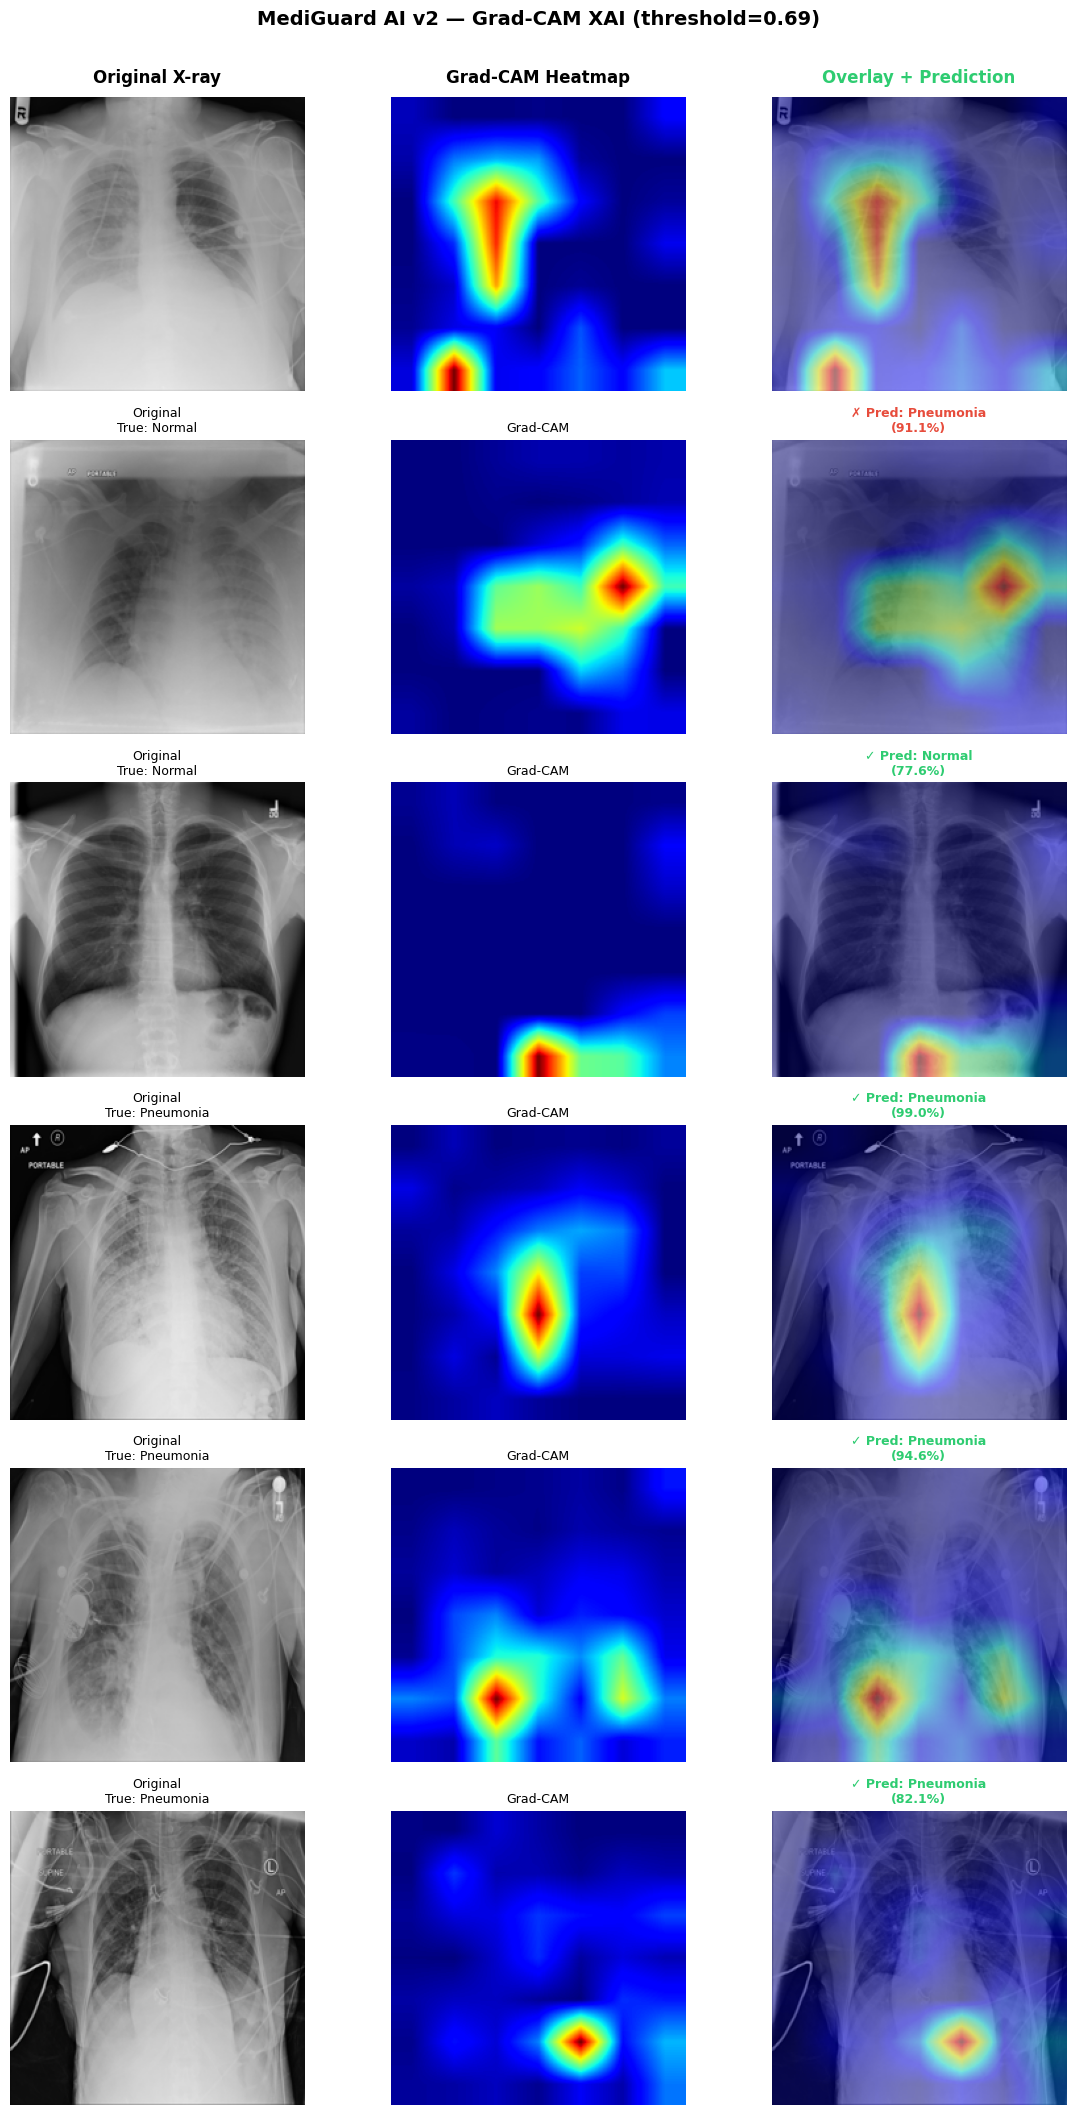

Saved → /kaggle/working/gradcam_v2.png


In [23]:
normal_s    = val_df[val_df['Target']==0].head(3)
pneumonia_s = val_df[val_df['Target']==1].head(3)
samples     = pd.concat([normal_s, pneumonia_s]).reset_index(drop=True)

fig, axes = plt.subplots(6, 3, figsize=(12, 21))

for i, (_, row) in enumerate(samples.iterrows()):
    img_path   = os.path.join(IMG_DIR, 'Images', row['patientId'] + '.png')
    true_label = 'Pneumonia' if row['Target']==1 else 'Normal'
    visualize_gradcam(img_path, true_label, model, grad_cam, device, axes[i])

for ax, col in zip(axes[0], ['Original X-ray', 'Grad-CAM Heatmap', 'Overlay + Prediction']):
    ax.set_title(col, fontsize=12, fontweight='bold', pad=10)

plt.suptitle(f'MediGuard AI v2 — Grad-CAM XAI (threshold={best_thresh:.2f})',
             fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'gradcam_v2.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {SAVE_DIR}gradcam_v2.png')

---
## 📋 Step 21: Project Summary

### MediGuard AI — Complete Feature Coverage

| Component | Status | Notes |
|---|---|---|
| Data Collection & Preprocessing | ✅ | 26,684 chest X-rays, stratified split |
| Class Imbalance Handling | ✅ **NEW** | WeightedRandomSampler + pos_weight=3.44 |
| ResNet50 Transfer Learning | ✅ | Pretrained ImageNet weights |
| 2-Phase Training | ✅ **NEW** | Phase 1: FC warmup → Phase 2: layer3+4 fine-tuning |
| Dropout Regularization | ✅ | p=0.4 on FC head |
| Data Augmentation | ✅ | Flip, rotation, color jitter |
| Early Stopping + Checkpointing | ✅ | Saves best F1-score model |
| Optimal Threshold Selection | ✅ **NEW** | Auto-found via ROC curve |
| Evaluation (Acc/Prec/Recall/F1/AUC) | ✅ | Full medical metrics |
| Confusion Matrix + ROC Curve | ✅ | With optimal threshold marked |
| Prediction System | ✅ | Single image → label + confidence |
| Grad-CAM XAI Heatmaps | ✅ | layer4 hooks, jet colourmap overlay |

### 📁 Output Files (`/kaggle/working/`)
| File | Description |
|---|---|
| `best_model.pth` | Best checkpoint (optimised for F1) |
| `training_curves_v2.png` | Loss, Recall, F1, AUC over epochs |
| `evaluation_v2.png` | Confusion matrix + ROC with optimal threshold |
| `gradcam_v2.png` | Grad-CAM heatmaps (6 validation samples) |

> ⚠️ MediGuard AI is a research tool and is **not intended to replace professional medical diagnosis.**
> Always consult a qualified radiologist for clinical decisions.

In [54]:
import pandas as pd
import os

BASE_INPUT = '/kaggle/input/datasets/iamtapendu/rsna-pneumonia-processed-dataset'

IMAGE_DIR = os.path.join(BASE_INPUT, 'Training', 'Images')

print(os.listdir(IMAGE_DIR)[:5])

df = pd.read_csv(
    os.path.join(BASE_INPUT, 'stage2_train_metadata.csv')
)

# pick one normal and one pneumonia
normal_sample = df[df['Target'] == 0].iloc[0]
pneumonia_sample = df[df['Target'] == 1].iloc[0]


normal_path = os.path.join(
    IMAGE_DIR,
    normal_sample['patientId'] + '.png'
)

pneumonia_path = os.path.join(
    IMAGE_DIR,
    pneumonia_sample['patientId'] + '.png'
)


print(normal_path)
print(pneumonia_path)

print(os.path.exists(normal_path))
print(os.path.exists(pneumonia_path))

['7a530f4d-13af-4e4e-bf2e-080c7fb27ffb.png', '86f084ef-539c-404b-9a91-c9a5d5ab3771.png', '673989cb-131a-43fc-8276-710c65ddb2d6.png', '85a77a2c-9fb8-4ceb-af2b-4de716d4d366.png', '9f756055-99fc-4a80-97b4-f89f98cf92d2.png']
/kaggle/input/datasets/iamtapendu/rsna-pneumonia-processed-dataset/Training/Images/0004cfab-14fd-4e49-80ba-63a80b6bddd6.png
/kaggle/input/datasets/iamtapendu/rsna-pneumonia-processed-dataset/Training/Images/00436515-870c-4b36-a041-de91049b9ab4.png
True
True


       MediGuard AI — Prediction Result
  Prediction : Pneumonia
  Confidence : 92.74%
  Raw Prob   : 0.9274

⚠️  This tool is for research purposes only.
   Always consult a qualified radiologist for clinical decisions.


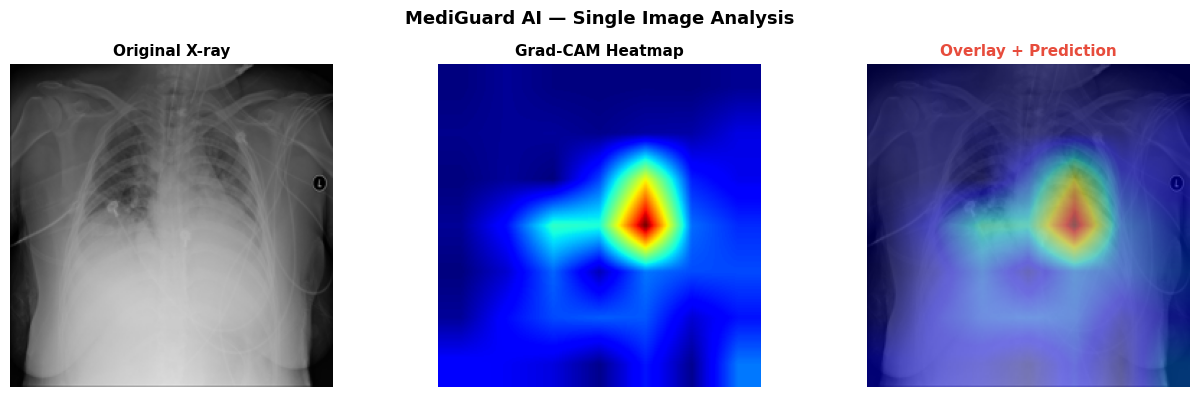

In [55]:
# ─── CHANGE THIS PATH to your own chest X-ray image ──────────────────────────
# Example: use any patientId from the dataset
TEST_PATIENT_ID = pneumonia_path   # ← replace with any ID or your own path
TEST_IMG_PATH   = os.path.join(IMG_DIR, 'Images', TEST_PATIENT_ID)
TEST_TRUE_LABEL = 'Pneumonia' if val_df.iloc[0]['Target'] == 1 else 'Normal'

# For your own uploaded image:
# TEST_IMG_PATH = '/kaggle/working/my_xray.png'
# TEST_TRUE_LABEL = 'Unknown'

# ── Run prediction ────────────────────────────────────────────────────────────
result = predict_single_image(TEST_IMG_PATH, model, device)

print('=' * 45)
print('       MediGuard AI — Prediction Result')
print('=' * 45)
print(f"  Prediction : {result['label']}")
print(f"  Confidence : {result['confidence']}%")
print(f"  Raw Prob   : {result['raw_prob']}")
print('=' * 45)
print()
print('⚠️  This tool is for research purposes only.')
print('   Always consult a qualified radiologist for clinical decisions.')

# ── Grad-CAM explanation ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
visualize_gradcam(TEST_IMG_PATH, TEST_TRUE_LABEL, model, grad_cam, device,
                  ax_row=axes)
for ax, col_title in zip(axes, ['Original X-ray', 'Grad-CAM Heatmap', 'Overlay + Prediction']):
    ax.set_title(col_title, fontsize=11, fontweight='bold')
plt.suptitle('MediGuard AI — Single Image Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'single_prediction.png'), dpi=150)
plt.show()



       MediGuard AI — Prediction Result
  Prediction : Pneumonia
  Confidence : 84.67%
  Raw Prob   : 0.8467

⚠️  This tool is for research purposes only.
   Always consult a qualified radiologist for clinical decisions.


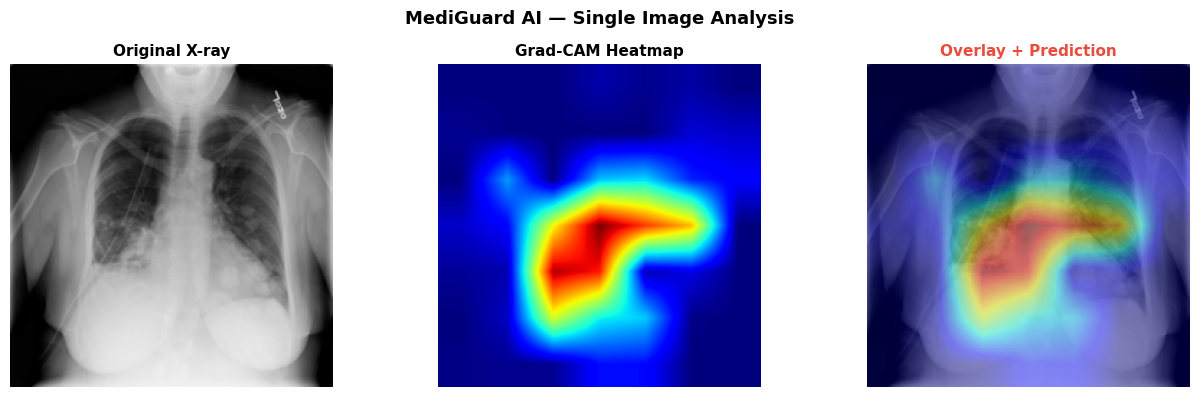

In [56]:
# ─── CHANGE THIS PATH to your own chest X-ray image ──────────────────────────
# Example: use any patientId from the dataset
TEST_PATIENT_ID = normal_path   # ← replace with any ID or your own path
TEST_IMG_PATH   = os.path.join(IMG_DIR, 'Images', TEST_PATIENT_ID)
TEST_TRUE_LABEL = 'Pneumonia' if val_df.iloc[0]['Target'] == 1 else 'Normal'

# For your own uploaded image:
# TEST_IMG_PATH = '/kaggle/working/my_xray.png'
# TEST_TRUE_LABEL = 'Unknown'

# ── Run prediction ────────────────────────────────────────────────────────────
result = predict_single_image(TEST_IMG_PATH, model, device)

print('=' * 45)
print('       MediGuard AI — Prediction Result')
print('=' * 45)
print(f"  Prediction : {result['label']}")
print(f"  Confidence : {result['confidence']}%")
print(f"  Raw Prob   : {result['raw_prob']}")
print('=' * 45)
print()
print('⚠️  This tool is for research purposes only.')
print('   Always consult a qualified radiologist for clinical decisions.')

# ── Grad-CAM explanation ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
visualize_gradcam(TEST_IMG_PATH, TEST_TRUE_LABEL, model, grad_cam, device,
                  ax_row=axes)
for ax, col_title in zip(axes, ['Original X-ray', 'Grad-CAM Heatmap', 'Overlay + Prediction']):
    ax.set_title(col_title, fontsize=11, fontweight='bold')
plt.suptitle('MediGuard AI — Single Image Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'single_prediction.png'), dpi=150)
plt.show()



       MediGuard AI — Prediction Result
  Prediction : Normal
  Confidence : 37.07%
  Raw Prob   : 0.6293

⚠️  This tool is for research purposes only.
   Always consult a qualified radiologist for clinical decisions.


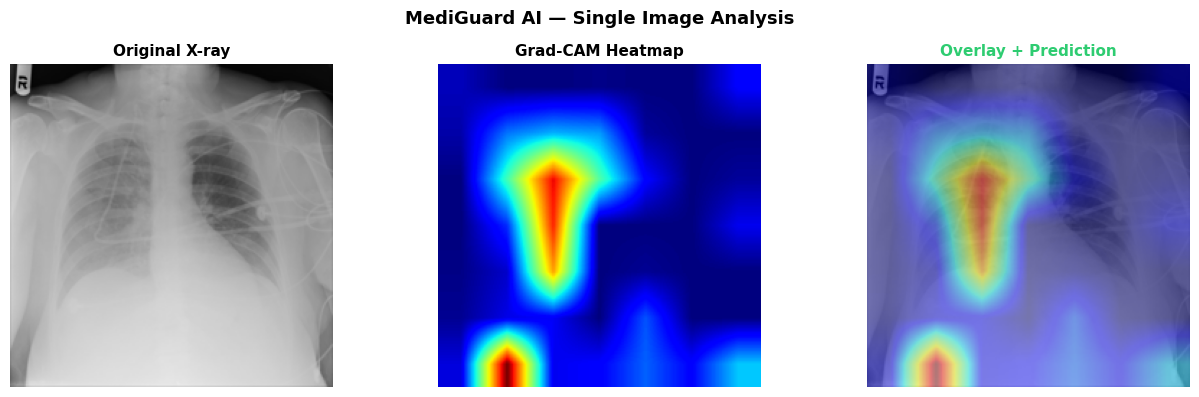

In [57]:
# ─── CHANGE THIS PATH to your own chest X-ray image ──────────────────────────
# Example: use any patientId from the dataset
TEST_PATIENT_ID = val_df.iloc[0]['patientId']   # ← replace with any ID or your own path
TEST_IMG_PATH   = os.path.join(IMG_DIR, 'Images', TEST_PATIENT_ID + '.png')
TEST_TRUE_LABEL = 'Pneumonia' if val_df.iloc[0]['Target'] == 1 else 'Normal'

# For your own uploaded image:
# TEST_IMG_PATH = '/kaggle/working/my_xray.png'
# TEST_TRUE_LABEL = 'Unknown'

# ── Run prediction ────────────────────────────────────────────────────────────
result = predict_single_image(TEST_IMG_PATH, model, device)

print('=' * 45)
print('       MediGuard AI — Prediction Result')
print('=' * 45)
print(f"  Prediction : {result['label']}")
print(f"  Confidence : {result['confidence']}%")
print(f"  Raw Prob   : {result['raw_prob']}")
print('=' * 45)
print()
print('⚠️  This tool is for research purposes only.')
print('   Always consult a qualified radiologist for clinical decisions.')

# ── Grad-CAM explanation ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
visualize_gradcam(TEST_IMG_PATH, TEST_TRUE_LABEL, model, grad_cam, device,
                  ax_row=axes)
for ax, col_title in zip(axes, ['Original X-ray', 'Grad-CAM Heatmap', 'Overlay + Prediction']):
    ax.set_title(col_title, fontsize=11, fontweight='bold')
plt.suptitle('MediGuard AI — Single Image Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'single_prediction.png'), dpi=150)
plt.show()



       MediGuard AI — Prediction Result
  Prediction : Normal
  Confidence : 37.07%
  Raw Prob   : 0.6293

⚠️  This tool is for research purposes only.
   Always consult a qualified radiologist for clinical decisions.


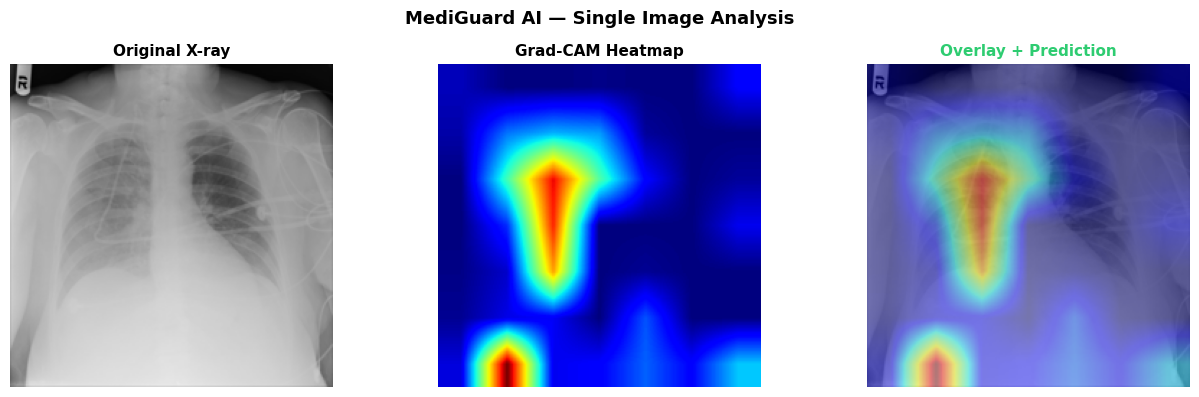

In [58]:
# ── Test on a NORMAL sample ───────────────────────────────────────────────────
TEST_IMG_PATH   = os.path.join(IMG_DIR, 'Images', val_df[val_df['Target']==0].iloc[0]['patientId'] + '.png')
TEST_TRUE_LABEL = 'Normal'

# ── Test on a PNEUMONIA sample ────────────────────────────────────────────────
# TEST_IMG_PATH   = os.path.join(IMG_DIR, 'Images', val_df[val_df['Target']==1].iloc[0]['patientId'] + '.png')
# TEST_TRUE_LABEL = 'Pneumonia'

# ── Run prediction ────────────────────────────────────────────────────────────
result = predict_single_image(TEST_IMG_PATH, model, device)
print('=' * 45)
print('       MediGuard AI — Prediction Result')
print('=' * 45)
print(f"  Prediction : {result['label']}")
print(f"  Confidence : {result['confidence']}%")
print(f"  Raw Prob   : {result['raw_prob']}")
print('=' * 45)
print()
print('⚠️  This tool is for research purposes only.')
print('   Always consult a qualified radiologist for clinical decisions.')

# ── Grad-CAM explanation ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
visualize_gradcam(TEST_IMG_PATH, TEST_TRUE_LABEL, model, grad_cam, device, ax_row=axes)
for ax, col_title in zip(axes, ['Original X-ray', 'Grad-CAM Heatmap', 'Overlay + Prediction']):
    ax.set_title(col_title, fontsize=11, fontweight='bold')
plt.suptitle('MediGuard AI — Single Image Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'single_prediction.png'), dpi=150)
plt.show()

       MediGuard AI — Prediction Result
  Prediction : Pneumonia
  Confidence : 98.97%
  Raw Prob   : 0.9897

⚠️  This tool is for research purposes only.
   Always consult a qualified radiologist for clinical decisions.


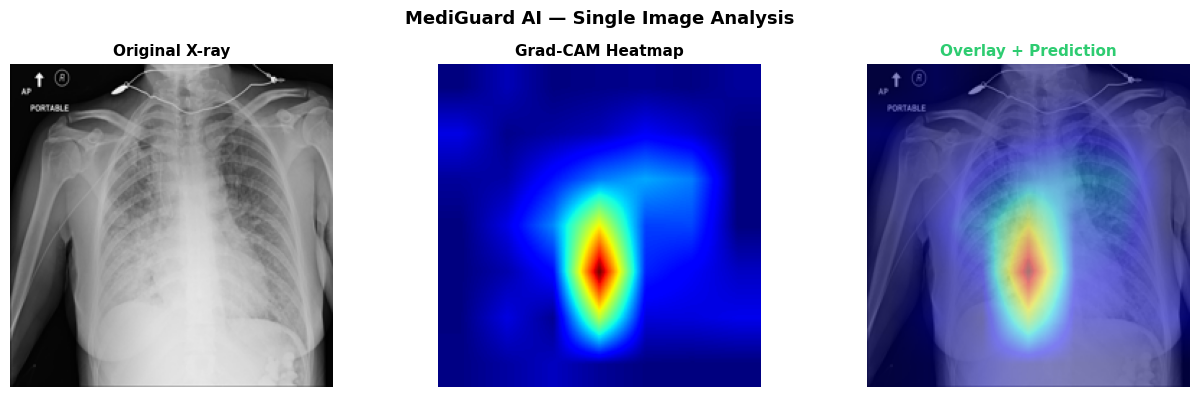

In [59]:
# ── Test on a NORMAL sample ───────────────────────────────────────────────────
# TEST_IMG_PATH   = os.path.join(IMG_DIR, 'Images', val_df[val_df['Target']==0].iloc[0]['patientId'] + '.png')
# TEST_TRUE_LABEL = 'Normal'

# ── Test on a PNEUMONIA sample ────────────────────────────────────────────────
TEST_IMG_PATH   = os.path.join(IMG_DIR, 'Images', val_df[val_df['Target']==1].iloc[0]['patientId'] + '.png')
TEST_TRUE_LABEL = 'Pneumonia'

# ── Run prediction ────────────────────────────────────────────────────────────
result = predict_single_image(TEST_IMG_PATH, model, device)
print('=' * 45)
print('       MediGuard AI — Prediction Result')
print('=' * 45)
print(f"  Prediction : {result['label']}")
print(f"  Confidence : {result['confidence']}%")
print(f"  Raw Prob   : {result['raw_prob']}")
print('=' * 45)
print()
print('⚠️  This tool is for research purposes only.')
print('   Always consult a qualified radiologist for clinical decisions.')

# ── Grad-CAM explanation ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
visualize_gradcam(TEST_IMG_PATH, TEST_TRUE_LABEL, model, grad_cam, device, ax_row=axes)
for ax, col_title in zip(axes, ['Original X-ray', 'Grad-CAM Heatmap', 'Overlay + Prediction']):
    ax.set_title(col_title, fontsize=11, fontweight='bold')
plt.suptitle('MediGuard AI — Single Image Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'single_prediction.png'), dpi=150)
plt.show()

In [24]:
from sklearn.metrics import confusion_matrix, f1_score

print(f'{"Threshold":<12} {"Recall":<10} {"Precision":<12} {"F1":<8} {"FP":<8} {"FN"}')
print('-' * 58)

for t in [0.50, 0.55, 0.60, 0.65, 0.69, 0.72, 0.75, 0.80]:
    preds = (np.array(all_probs_v) >= t).astype(float)
    tn, fp, fn, tp = confusion_matrix(all_labels_v, preds).ravel()
    recall    = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1        = f1_score(all_labels_v, preds, zero_division=0)
    current   = ' ← current' if t == 0.69 else ''
    print(f'{t:<12.2f} {recall:<10.3f} {precision:<12.3f} {f1:<8.3f} {fp:<8} {fn}{current}')

Threshold    Recall     Precision    F1       FP       FN
----------------------------------------------------------
0.50         0.945      0.383        0.545    1833     66
0.55         0.933      0.398        0.558    1696     80
0.60         0.918      0.416        0.572    1551     98
0.65         0.895      0.432        0.583    1412     126
0.69         0.866      0.451        0.594    1265     161 ← current
0.72         0.845      0.469        0.604    1149     186
0.75         0.832      0.492        0.618    1034     202
0.80         0.768      0.529        0.626    823      279


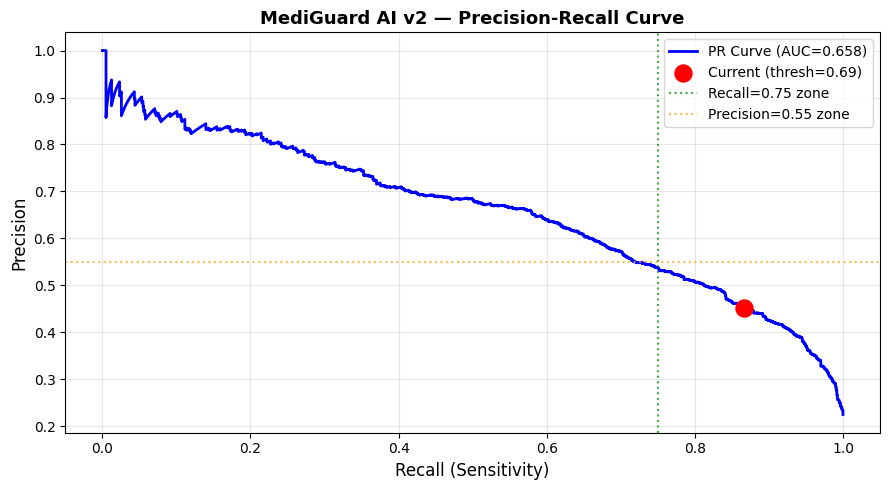

In [25]:
from sklearn.metrics import precision_recall_curve, auc

precision_vals, recall_vals, thresholds_pr = precision_recall_curve(
    all_labels_v, all_probs_v
)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(9, 5))
plt.plot(recall_vals, precision_vals, 'b-', lw=2, label=f'PR Curve (AUC={pr_auc:.3f})')

# Mark current operating point
plt.scatter(0.866, 0.4514, color='red', s=150, zorder=5,
            label='Current (thresh=0.69)')

# Mark a better balanced point
plt.axvline(0.75, color='green', ls=':', alpha=0.7, label='Recall=0.75 zone')
plt.axhline(0.55, color='orange', ls=':', alpha=0.7, label='Precision=0.55 zone')

plt.xlabel('Recall (Sensitivity)', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('MediGuard AI v2 — Precision-Recall Curve', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/precision_recall_curve.png', dpi=150)
plt.show()

In [26]:
# Change this to whichever threshold you want to use
MY_THRESHOLD = 0.75   # ← adjust based on Step 1 table

preds_new = (np.array(all_probs_v) >= MY_THRESHOLD).astype(float)
tn, fp, fn, tp = confusion_matrix(all_labels_v, preds_new).ravel()

print('=' * 50)
print(f'  Threshold  : {MY_THRESHOLD}')
print(f'  Recall     : {tp/(tp+fn):.4f}  ({tp}/{tp+fn} pneumonia caught)')
print(f'  Precision  : {tp/(tp+fp):.4f}  (when predicted pneumonia, this % correct)')
print(f'  F1-Score   : {f1_score(all_labels_v, preds_new):.4f}')
print(f'  FP         : {fp}  (normal cases wrongly flagged)')
print(f'  FN         : {fn}  (pneumonia cases missed)')
print('=' * 50)

  Threshold  : 0.75
  Recall     : 0.8319  (1000/1202 pneumonia caught)
  Precision  : 0.4916  (when predicted pneumonia, this % correct)
  F1-Score   : 0.6180
  FP         : 1034  (normal cases wrongly flagged)
  FN         : 202  (pneumonia cases missed)


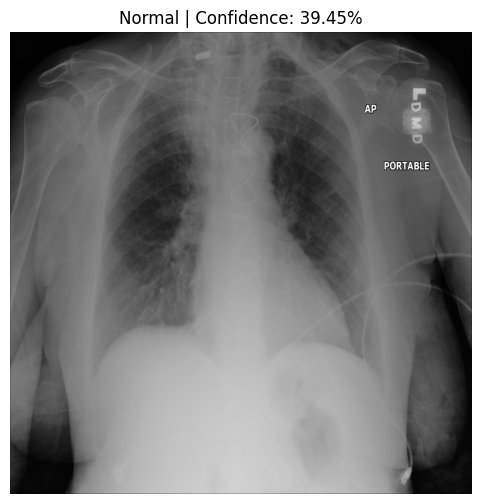

{'label': 'Normal', 'confidence': 39.45, 'raw_prob': 0.6055, 'threshold_used': 0.75}


In [53]:
import matplotlib.pyplot as plt
from PIL import Image

img_path = "/kaggle/input/datasets/iamtapendu/rsna-pneumonia-processed-dataset/Test/0015597f-2d69-4bc7-b642-5b5e01534676.png"

result = predict_single_image(
    img_path,
    model,
    device,
    threshold=0.75
)

img = Image.open(img_path)

plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title(f"{result['label']} | Confidence: {result['confidence']}%")
plt.show()

print(result)

In [50]:
import inspect
print(inspect.signature(predict_single_image))

(img_path, model, device, threshold=None)
